# **Ch 1. Exam Score Analysis**


## <span style="color: blue;">**1. Upload & Analyze Exam Scores**</span>

![Exam](https://raw.githubusercontent.com/pilsunchoi/images4/main/1-1.png)

Source: Exam scores (virtual) CSV file


## **Claude Analysis**

Here are the results of analyzing the grade data for a total of **73** students.

---

**📊 Overall Score Summary**

| Item | Mean | Min | Max |
|------|------|------|------|
| Midterm | 71.9 | 29.5 | 100.0 |
| Final | 72.8 | 34.0 | 98.5 |
| Attendance | 9.4 | 3.5 | 10.0 |
| Interest | 98.8 | 82.8 | 100.0 |

---

**🔍 Key Insights**

**Student Composition** — Department T dominates with 45 students (62%), 3rd-year students (44) make up the majority, and female students (51) account for a higher proportion.

**Midterm–Final Correlation** — The correlation coefficient is **0.883**, which is very high. Students who scored well on the midterm tended to score well on the final as well.

**Gender Differences** — Male students (midterm 77.0 / final 75.7) scored higher on average than female students (midterm 69.7 / final 71.6), though attendance was similar.

**Year-Level Differences** — 2nd-year students (midterm 82.4 / final 80.7) scored higher than 3rd and 4th-year students. Note that the sample size is only 7, so interpretation should be cautious.

**Course Type Differences** — General Elective (82.0 / 80.2) > Multi Elective (75.1 / 74.1) > Major Elective (70.1 / 71.8), with Major Elective students scoring relatively lower.

**Late Registration** — 15 students (21%) registered late, and interest scores were mostly close to 100.

---

### Graphs

**① Midterm / Final Score Distribution (Histogram)**
Shows the overlapping distributions of midterm and final scores. Both exams have means (dashed lines) in the low 70s, with wide distributions indicating considerable score variation among students.

![Exam](https://raw.githubusercontent.com/pilsunchoi/images4/main/1-2.png)

**② Midterm vs Final Score (Scatter Plot)**
Shows the relationship between midterm and final scores. With a correlation coefficient of r=0.88, the trend line has a steep slope, clearly showing that students who did well on the midterm also tended to do well on the final. Point colors represent year level.

![Exam](https://raw.githubusercontent.com/pilsunchoi/images4/main/1-3.png)

**③ Score Distribution by Gender (Box Plot)**
Compares midterm and final score distributions by gender using box plots. The median for male students is slightly higher, and there are more low-score outliers on the female side.

![Exam](https://raw.githubusercontent.com/pilsunchoi/images4/main/1-4.png)

**④ Average Score by Department (Horizontal Bar)**
Compares midterm and final averages by department. Dashed lines represent overall averages. Departments A, G, and H are above average, while some like P, F, and B fall below. Note that apart from Department T, most have small sample sizes, so interpretation should be cautious.

![Exam](https://raw.githubusercontent.com/pilsunchoi/images4/main/1-5.png)

**⑤ Average Score by Course Type (Bar)**
Compares averages by course type (Major Elective, Multi Elective, General Elective). General Elective > Multi Elective > Major Elective, with Major Elective students scoring relatively lower.

![Exam](https://raw.githubusercontent.com/pilsunchoi/images4/main/1-6.png)

**⑥ Attendance vs Total Score (Scatter Plot)**
Shows the relationship between attendance score and midterm+final total by gender. Since attendance scores cluster around 9–10 points, no clear correlation between attendance and academic performance is observed.

![Exam](https://raw.githubusercontent.com/pilsunchoi/images4/main/1-7.png)


## <span style="color: blue;">**2. Are late-registered students' scores relatively lower?**</span>


## **Claude Analysis**

Let's compare scores by late registration status.

![Exam](https://raw.githubusercontent.com/pilsunchoi/images4/main/1-8.png)

![Exam](https://raw.githubusercontent.com/pilsunchoi/images4/main/1-9.png)

![Exam](https://raw.githubusercontent.com/pilsunchoi/images4/main/1-10.png)

**Conclusion: Late-registered students tend to have lower scores, but the difference is not statistically significant.**

| Item | Regular (n=58) | Late Registration (n=15) | Difference |
|------|------------|----------------|------|
| Midterm | 73.1 | 67.5 | -5.6 |
| Final | 73.2 | 71.5 | -1.7 |
| Total | 146.3 | 139.0 | -7.3 |
| Attendance | 9.36 | 9.40 | +0.04 |
| Interest | 98.6 | 99.8 | +1.2 |

Numerically, late-registered students' midterm scores are about 5.6 points lower, but all items show **p-value > 0.05** (n.s.), making it difficult to consider this a statistically significant difference. The small sample size of 15 late-registered students, which reduces statistical power, should also be taken into account.

Interestingly, attendance and interest scores are slightly higher for late-registered students, suggesting they may be more actively engaged in the course.


## <span style="color: blue;">**3. Explain the meaning**</span>

<span style="color: blue;">**p-value > 0.05 (n.s.) means the difference is not statistically significant**</span>


## **Claude Analysis**

Here's an easy explanation.

**What is a p-value?**
"The probability that a score difference of this magnitude could occur purely by chance."

- p = 0.330 (midterm) → This means there is a 33% probability that this difference could occur by chance alone
- Typically, when **p < 0.05 (5%)**, we conclude that "the probability of this being due to chance is too low — there is a real difference"

**Applying this to our data:**

The midterm average for late-registered students is 5.6 points lower, but there are only **15** students in the late-registration group. When the sample size is small, even if a real score difference exists, we cannot statistically rule out the possibility that "it was just by chance that lower-scoring students happened to cluster together."

**An analogy:**

If you flip a coin 10 times and get 7 heads, it's hard to be confident that "this coin favors heads." But if you flip it 1,000 times and get 700 heads, you can be confident. The larger the sample, the more reliable even the same difference becomes.

**Summary**

| | This Result |
|---|---|
| Score difference | Exists (midterm -5.6 points) |
| Statistical confidence | None (sample of 15 is too small) |
| Conclusion | "It seems lower, but we cannot say for certain" |

If there had been more late-registered students (e.g., 50 or more), the same difference likely would have been statistically significant.


## **Reference: Python Code**


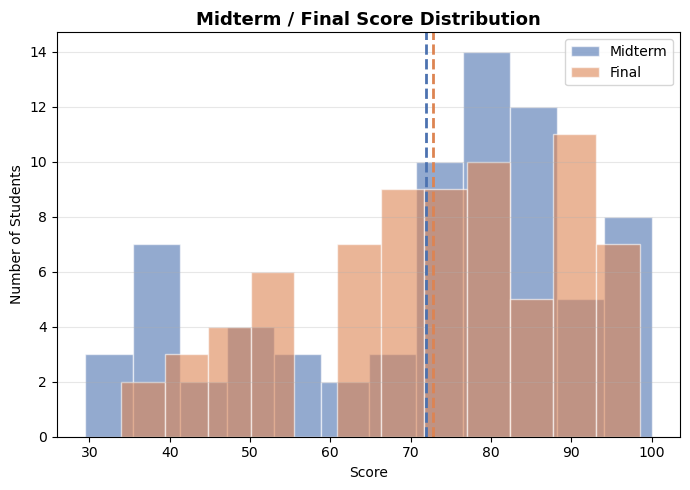

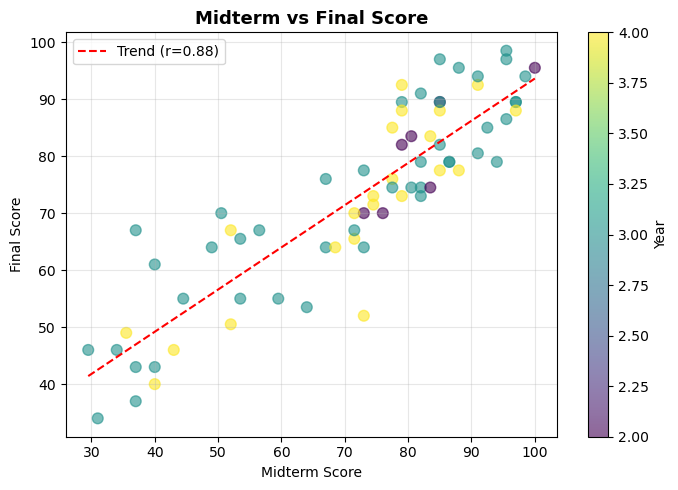

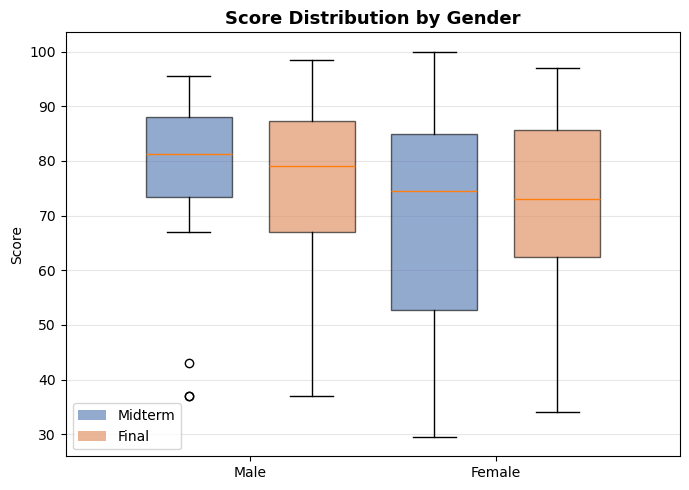

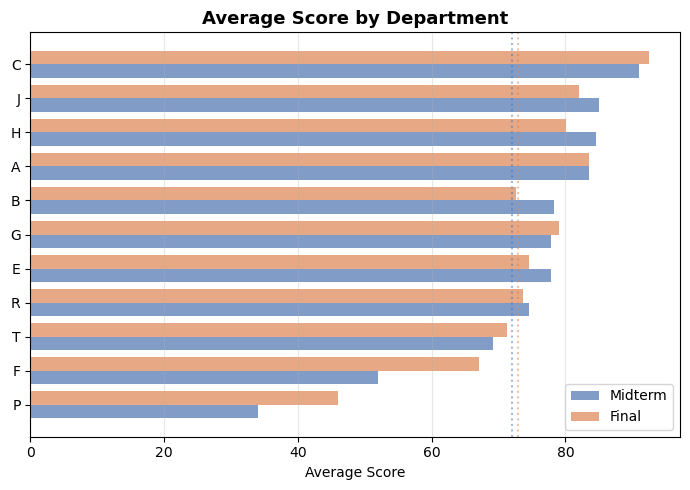

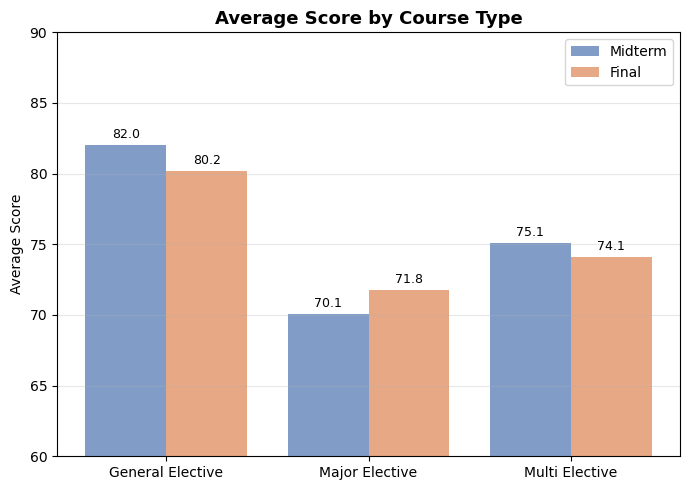

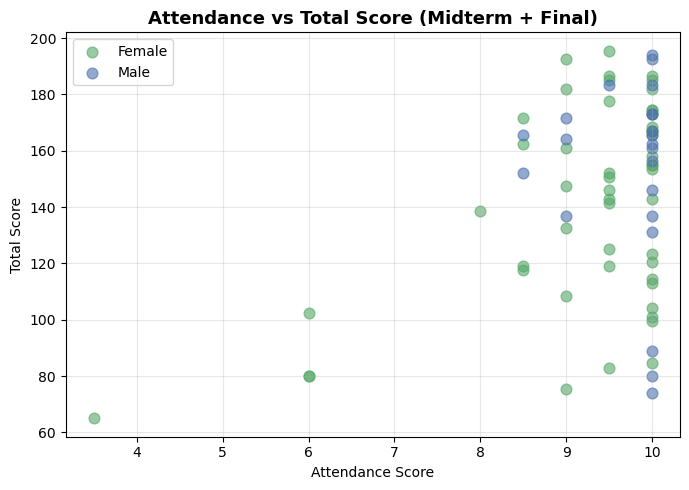

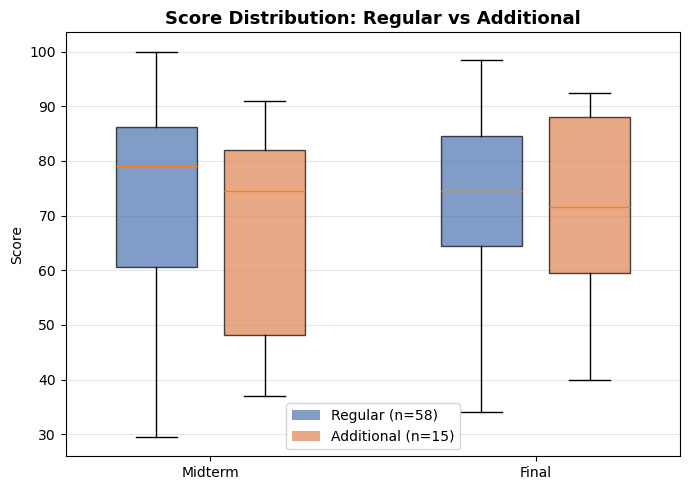

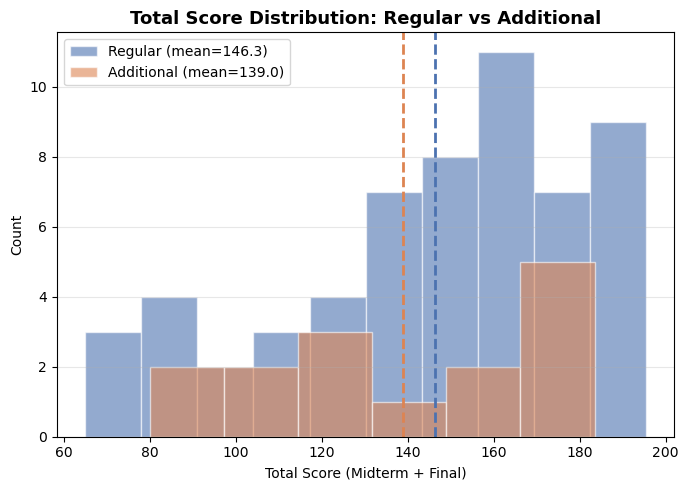

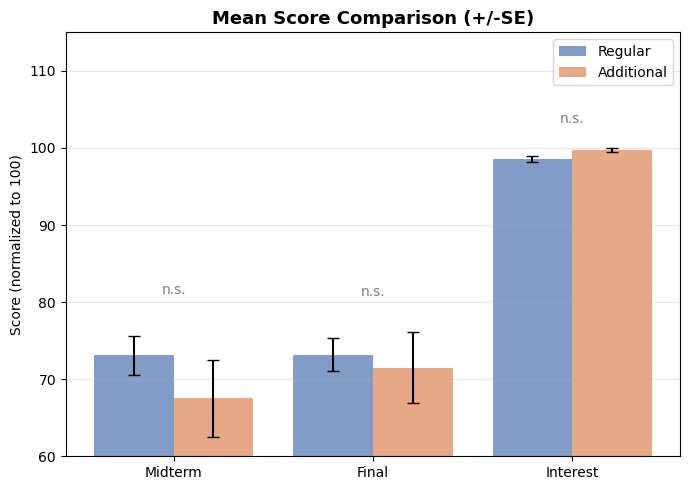

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy import stats

# ============================================================
# 1. Load data
# ============================================================
df = pd.read_csv('../Data/exam.csv', encoding='utf-8-sig')

df = df.rename(columns={
    '중간고사': 'Midterm',
    '기말고사': 'Final',
    '학년': 'Year',
    '성별': 'Gender',
    '학과': 'Department',
    '이수구분': 'CourseType',
    '출석': 'Attendance',
    '추가신청': 'LateReg',
    '관심도': 'Interest',
})
df['Gender'] = df['Gender'].map({'남': 'M', '여': 'F'})
df['CourseType'] = df['CourseType'].map({
    '전선': 'Major Elective',
    '다선': 'Multi Elective',
    '일선': 'General Elective',
})
df['Total'] = df['Midterm'] + df['Final']

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']

# ============================================================
# Graph 1: Midterm/Final score histogram
# ============================================================
fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(df['Midterm'], bins=12, alpha=0.6, color=colors[0], label='Midterm', edgecolor='white')
ax.hist(df['Final'], bins=12, alpha=0.6, color=colors[1], label='Final', edgecolor='white')
ax.axvline(df['Midterm'].mean(), color=colors[0], linestyle='--', linewidth=2)
ax.axvline(df['Final'].mean(), color=colors[1], linestyle='--', linewidth=2)
ax.set_title('Midterm / Final Score Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Score')
ax.set_ylabel('Number of Students')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# Graph 2: Midterm vs Final scatter plot + trend line
# ============================================================
fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(df['Midterm'], df['Final'], alpha=0.6,
                     c=df['Year'], cmap='viridis', s=60)
z = np.polyfit(df['Midterm'], df['Final'], 1)
x_line = np.linspace(df['Midterm'].min(), df['Midterm'].max(), 100)
ax.plot(x_line, np.poly1d(z)(x_line), 'r--', linewidth=1.5,
        label=f'Trend (r={df["Midterm"].corr(df["Final"]):.2f})')
ax.set_title('Midterm vs Final Score', fontsize=13, fontweight='bold')
ax.set_xlabel('Midterm Score')
ax.set_ylabel('Final Score')
ax.legend()
ax.grid(alpha=0.3)
plt.colorbar(scatter, ax=ax, label='Year')
plt.tight_layout()
plt.show()

# ============================================================
# Graph 3: Score distribution box plot by gender
# ============================================================
fig, ax = plt.subplots(figsize=(7, 5))
data_m = df[df['Gender'] == 'M']
data_f = df[df['Gender'] == 'F']
# Male/Female x Midterm/Final -> 4 boxes arranged in 2 pairs
ax.boxplot([data_m['Midterm'], data_f['Midterm']], positions=[1, 2], widths=0.35,
           patch_artist=True, boxprops=dict(facecolor=colors[0], alpha=0.6))
ax.boxplot([data_m['Final'], data_f['Final']], positions=[1.5, 2.5], widths=0.35,
           patch_artist=True, boxprops=dict(facecolor=colors[1], alpha=0.6))
ax.set_xticks([1.25, 2.25])
ax.set_xticklabels(['Male', 'Female'])
ax.set_title('Score Distribution by Gender', fontsize=13, fontweight='bold')
ax.set_ylabel('Score')
ax.legend(handles=[Patch(facecolor=colors[0], alpha=0.6, label='Midterm'),
                   Patch(facecolor=colors[1], alpha=0.6, label='Final')])
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# Graph 4: Average score by department (horizontal bar)
# ============================================================
fig, ax = plt.subplots(figsize=(7, 5))
dept_avg = df.groupby('Department')[['Midterm', 'Final']].mean().sort_values('Midterm', ascending=True)
y_pos = np.arange(len(dept_avg))
ax.barh(y_pos - 0.2, dept_avg['Midterm'], height=0.4, color=colors[0], alpha=0.7, label='Midterm')
ax.barh(y_pos + 0.2, dept_avg['Final'], height=0.4, color=colors[1], alpha=0.7, label='Final')
ax.set_yticks(y_pos)
ax.set_yticklabels(dept_avg.index)
ax.set_title('Average Score by Department', fontsize=13, fontweight='bold')
ax.set_xlabel('Average Score')
ax.legend()
# Overall average shown as dotted lines
ax.axvline(df['Midterm'].mean(), color=colors[0], linestyle=':', alpha=0.5)
ax.axvline(df['Final'].mean(), color=colors[1], linestyle=':', alpha=0.5)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# Graph 5: Average score by course type (bar with values)
# ============================================================
fig, ax = plt.subplots(figsize=(7, 5))
isu_avg = df.groupby('CourseType')[['Midterm', 'Final']].mean()
x = np.arange(len(isu_avg))
bars1 = ax.bar(x - 0.2, isu_avg['Midterm'], 0.4, color=colors[0], alpha=0.7, label='Midterm')
bars2 = ax.bar(x + 0.2, isu_avg['Final'], 0.4, color=colors[1], alpha=0.7, label='Final')
ax.set_xticks(x)
ax.set_xticklabels(isu_avg.index)
ax.set_title('Average Score by Course Type', fontsize=13, fontweight='bold')
ax.set_ylabel('Average Score')
ax.set_ylim(60, 90)
# Display values on top of each bar
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 0.3,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 0.3,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# Graph 6: Attendance score vs Midterm+Final total scatter plot
# ============================================================
fig, ax = plt.subplots(figsize=(7, 5))
gender_colors = {'M': colors[0], 'F': colors[2]}
gender_labels = {'M': 'Male', 'F': 'Female'}
for gender, group in df.groupby('Gender'):
    ax.scatter(group['Attendance'], group['Total'], alpha=0.6,
               c=gender_colors[gender], label=gender_labels[gender], s=60)
ax.set_title('Attendance vs Total Score (Midterm + Final)', fontsize=13, fontweight='bold')
ax.set_xlabel('Attendance Score')
ax.set_ylabel('Total Score')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# Graph 7: Late registration - Midterm/Final box plot
# ============================================================
data_reg = df[df['LateReg'] == 0]
data_add = df[df['LateReg'] == 1]

fig, ax = plt.subplots(figsize=(7, 5))
bp = ax.boxplot(
    [data_reg['Midterm'], data_add['Midterm'],
     data_reg['Final'], data_add['Final']],
    positions=[1, 1.6, 2.8, 3.4], widths=0.45, patch_artist=True,
    boxprops=dict(alpha=0.7)
)
# Alternate box colors (blue=regular, orange=late registration)
for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor(colors[i % 2])
ax.set_xticks([1.3, 3.1])
ax.set_xticklabels(['Midterm', 'Final'])
ax.set_title('Score Distribution: Regular vs Additional', fontsize=13, fontweight='bold')
ax.set_ylabel('Score')
ax.legend(handles=[Patch(facecolor=colors[0], alpha=0.7, label='Regular (n=58)'),
                   Patch(facecolor=colors[1], alpha=0.7, label='Additional (n=15)')])
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# Graph 8: Late registration - Total score histogram comparison
# ============================================================
fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(data_reg['Total'], bins=10, alpha=0.6, color=colors[0],
        label=f'Regular (mean={data_reg["Total"].mean():.1f})', edgecolor='white')
ax.hist(data_add['Total'], bins=6, alpha=0.6, color=colors[1],
        label=f'Additional (mean={data_add["Total"].mean():.1f})', edgecolor='white')
ax.axvline(data_reg['Total'].mean(), color=colors[0], linestyle='--', linewidth=2)
ax.axvline(data_add['Total'].mean(), color=colors[1], linestyle='--', linewidth=2)
ax.set_title('Total Score Distribution: Regular vs Additional', fontsize=13, fontweight='bold')
ax.set_xlabel('Total Score (Midterm + Final)')
ax.set_ylabel('Count')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# Graph 9: Late registration - Mean comparison by item (+/- SE) + p-value
# ============================================================
fig, ax = plt.subplots(figsize=(7, 5))
metrics = ['Midterm', 'Final', 'Interest']
cols = ['Midterm', 'Final', 'Interest']

scale = [1, 1, 1]
means_reg = [data_reg[c].mean() / s for c, s in zip(cols, scale)]
means_add = [data_add[c].mean() / s for c, s in zip(cols, scale)]
sems_reg  = [data_reg[c].sem()  / s for c, s in zip(cols, scale)]
sems_add  = [data_add[c].sem()  / s for c, s in zip(cols, scale)]

x = np.arange(len(metrics))
ax.bar(x - 0.2, means_reg, 0.4, color=colors[0], alpha=0.7,
       label='Regular', yerr=sems_reg, capsize=4)
ax.bar(x + 0.2, means_add, 0.4, color=colors[1], alpha=0.7,
       label='Additional', yerr=sems_add, capsize=4)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_title('Mean Score Comparison (+/-SE)', fontsize=13, fontweight='bold')
ax.set_ylabel('Score (normalized to 100)')
ax.set_ylim(60, 115)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Display significance above each item (p < 0.05 -> *, otherwise -> n.s.)
for i, col in enumerate(cols):
    _, p_val = stats.ttest_ind(data_reg[col], data_add[col])
    y_top = max(means_reg[i], means_add[i]) + max(sems_reg[i], sems_add[i]) + 3
    ax.text(i, y_top, '*' if p_val < 0.05 else 'n.s.', ha='center', fontsize=10, color='gray')

plt.tight_layout()
plt.show()

